# Обучение и оценка

Прогнозируем `log1p` просмотров и лайков поста по тому, что известно до публикации. Схема такая:

**прогноз = текущий уровень сообщества + поправка модели**

Текущий уровень считается как медиана log-просмотров последних 20 постов (`level_views`). Модель учится предсказывать отклонение от него по тексту поста, времени публикации и темпу постинга. Так рост сообщества за 8 лет не мешает модели, а деревья и линейные модели не пытаются экстраполировать уровень, которого не видели в обучении

Разбиение по времени: обучаемся на первых 80% постов, проверяемся на последних 20%

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

from features import CALENDAR_FEATURES, META_FEATURES, MODELS_DIR, PREPARED_FILE

df = pd.read_csv(PREPARED_FILE, parse_dates=["Дата публикации"])
df["text"] = df["Текст поста"].fillna("").str.lower()

TARGETS = {"views": "Просмотры", "likes": "Лайки"}
cut = int(len(df) * 0.8)
train, test = df.iloc[:cut].copy(), df.iloc[cut:].copy()
print(f"train: {train['Дата публикации'].min():%Y-%m-%d} - {train['Дата публикации'].max():%Y-%m-%d}, {len(train)} постов")
print(f"test:  {test['Дата публикации'].min():%Y-%m-%d} - {test['Дата публикации'].max():%Y-%m-%d}, {len(test)} постов")

train: 2017-01-04 - 2023-04-04, 3907 постов
test:  2023-04-05 - 2025-08-02, 977 постов


In [2]:
def metrics(y_true_log, y_pred_log):
    """R² в логарифме + ошибки в исходных единицах"""
    true, pred = np.expm1(y_true_log), np.expm1(y_pred_log)
    return {
        "R² (log)": round(r2_score(y_true_log, y_pred_log), 3),
        "MAE": round(mean_absolute_error(true, pred)),
        "медианная ошибка, %": round(100 * np.median(np.abs(pred - true) / np.maximum(true, 1)), 1),
    }


def fill_level(frame, name, fallback):
    return frame[f"level_{name}"].fillna(fallback).values

## Новая модель

Признаки:

- текст поста: TF-IDF по символьным n-граммам (2-5 символов). Для русского языка с падежами и хештегами это работает лучше, чем слова целиком
- мета-признаки текста: длина, число слов, эмодзи, хештеги, ссылки, наличие счёта матча вида «2:1», восклицательные знаки
- час и день недели (one-hot, потому что зависимость от часа не монотонная)
- темп постинга: часов с прошлого поста, сколько постов вышло за сутки

Модель: Ridge-регрессия на отклонение от текущего уровня. Силу регуляризации подбираем на последних 20% обучающей выборки, чтобы не подглядывать в тест

In [3]:
def make_model(alpha):
    features = ColumnTransformer([
        ("text", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=5,
                                 sublinear_tf=True, max_features=60000), "text"),
        ("meta", Pipeline([("log", FunctionTransformer(np.log1p)), ("scale", StandardScaler())]), META_FEATURES),
        ("calendar", OneHotEncoder(handle_unknown="ignore"), CALENDAR_FEATURES),
    ])
    return Pipeline([("features", features), ("ridge", Ridge(alpha=alpha))])


def pick_alpha(frame, name, col, alphas=(1, 3, 10, 30)):
    inner = int(len(frame) * 0.8)
    fit, val = frame.iloc[:inner], frame.iloc[inner:]
    fallback = np.log1p(fit[col]).median()
    scores = {}
    for a in alphas:
        m = make_model(a).fit(fit, np.log1p(fit[col]) - fill_level(fit, name, fallback))
        pred = fill_level(val, name, fallback) + m.predict(val)
        scores[a] = r2_score(np.log1p(val[col]), pred)
    return max(scores, key=scores.get), scores


results, predictions, alphas = {}, {}, {}
for name, col in TARGETS.items():
    alpha, scores = pick_alpha(train, name, col)
    alphas[name] = alpha
    print(f"{name}: R² на валидации по alpha {dict((k, round(v, 3)) for k, v in scores.items())} -> alpha = {alpha}")

    fallback = np.log1p(train[col]).median()
    y_train = np.log1p(train[col]) - fill_level(train, name, fallback)
    model = make_model(alpha).fit(train, y_train)

    y_test = np.log1p(test[col]).values
    baseline = fill_level(test, name, fallback)
    pred = baseline + model.predict(test)
    predictions[name] = (y_test, pred)
    results[(name, "уровень последних 20 постов")] = metrics(y_test, baseline)
    results[(name, "уровень + Ridge")] = metrics(y_test, pred)

pd.DataFrame(results).T

views: R² на валидации по alpha {1: 0.181, 3: 0.188, 10: 0.172, 30: 0.152} -> alpha = 3


likes: R² на валидации по alpha {1: 0.171, 3: 0.2, 10: 0.173, 30: 0.129} -> alpha = 3


R² (log)     MAE  медианная ошибка, %
views уровень последних 20 постов     0.118  3660.0                 45.7
      уровень + Ridge                 0.218  3535.0                 45.5
likes уровень последних 20 постов    -0.050   124.0                 52.8
      уровень + Ridge                 0.188   113.0                 47.0

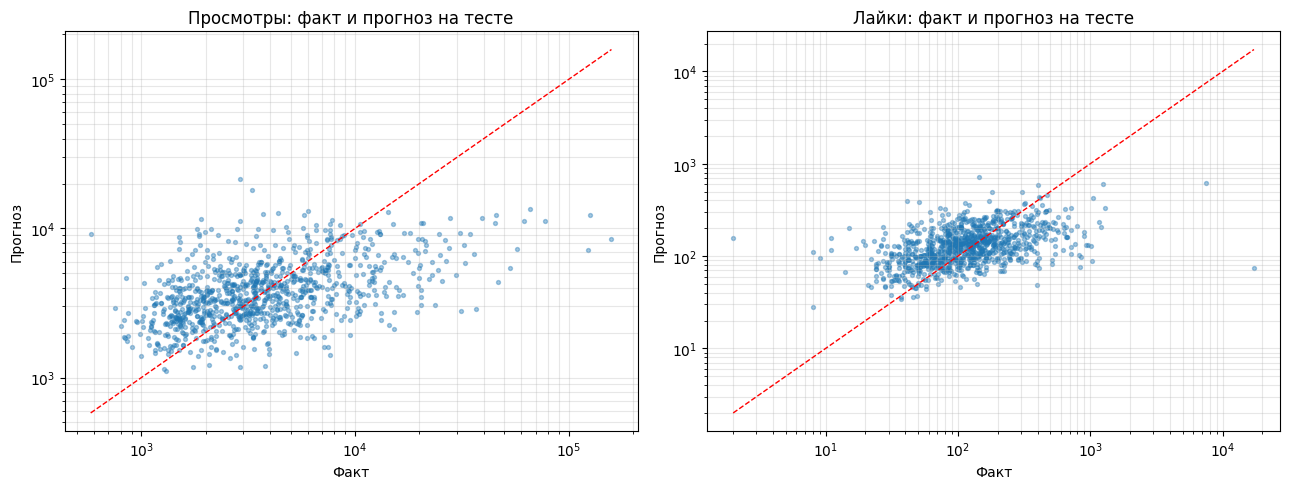

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, (y_true, y_pred)) in zip(axes, predictions.items()):
    ax.scatter(np.expm1(y_true), np.expm1(y_pred), s=8, alpha=0.4)
    lims = [max(1, np.expm1(y_true).min()), np.expm1(y_true).max()]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"{TARGETS[name]}: факт и прогноз на тесте")
    ax.set_xlabel("Факт")
    ax.set_ylabel("Прогноз")
    ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("../images/test_predictions.png", bbox_inches="tight")
plt.show()

## Что модель выучила

Самые сильные символьные n-граммы в модели просмотров. Положительный вес значит, что посты с этим фрагментом набирают больше обычного

In [5]:
def top_ngrams(model, k=15):
    tfidf = model.named_steps["features"].named_transformers_["text"]
    coefs = model.named_steps["ridge"].coef_[: len(tfidf.vocabulary_)]
    vocab = np.array(tfidf.get_feature_names_out())
    order = np.argsort(coefs)
    return pd.DataFrame({"вниз": vocab[order[:k]], "вверх": vocab[order[::-1][:k]]})

fallback = np.log1p(train["Просмотры"]).median()
views_model = make_model(alphas["views"]).fit(train, np.log1p(train["Просмотры"]) - fill_level(train, "views", fallback))
top_ngrams(views_model)

,вниз,вверх
0,',🇷🇺
1,д,🇷
2,о,🇷🇺
3,ka,🇷🇸
4,1,ом
5,ло,2
6,ka,фан
7,️⃣,пион
8,бзор,се
9,обзор,⚽


## Финальная модель

Переобучаем на всех данных и сохраняем. `predict.py` берёт уровень сообщества из последних 20 постов в `data/vk_posts_prepared.csv`

In [6]:
MODELS_DIR.mkdir(exist_ok=True)
bundle = {}
for name, col in TARGETS.items():
    fallback = np.log1p(df[col]).median()
    model = make_model(alphas[name]).fit(df, np.log1p(df[col]) - fill_level(df, name, fallback))
    bundle[name] = model
joblib.dump(bundle, MODELS_DIR / "engagement_model.joblib", compress=3)
print("Сохранено:", (MODELS_DIR / "engagement_model.joblib").relative_to(MODELS_DIR.parent))

Сохранено: models/engagement_model.joblib
